### Customer Churn Predictor

Pobranie i załadowanie danych

In [29]:
import os
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [30]:
file_path = kagglehub.dataset_download('gauravtopre/bank-customer-churn-dataset')
print(f'File path: {file_path}')

files = os.listdir(file_path)
print(files)

File path: C:\Users\patry\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1
['Bank Customer Churn Prediction.csv']


In [31]:
csv_path = os.path.join(file_path, files[0])
print(csv_path)

C:\Users\patry\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1\Bank Customer Churn Prediction.csv


In [32]:
data = pd.read_csv(csv_path)
print(data.info())
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


### 2. Preprocessing

Czyszczenie danych, uzupełnianie braków, zamiana wartości kategorycznych itp

In [33]:
cols_missing_val = data.isnull().sum()
print(cols_missing_val)

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


Wniosek: Nasz df nie zawiera brakujących danych.

In [34]:
# Chcę zobaczyć jaka jest rozpiętość zakresów w kolumnach numerycznych
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_stats = data[numerical_cols].describe()
print(num_stats.loc[['min', 'max']].transpose())

                          min          max
customer_id       15565701.00  15815690.00
credit_score           350.00       850.00
age                     18.00        92.00
tenure                   0.00        10.00
balance                  0.00    250898.09
products_number          1.00         4.00
credit_card              0.00         1.00
active_member            0.00         1.00
estimated_salary        11.58    199992.48
churn                    0.00         1.00


Wniosek: Ze względu na dużą różnicę rozpiętości danych między różnymi kolumnami należy przeprowadzić operację skalowania.

In [35]:
# Chcę policzyć ile jest różnych wartości w kolumnach kategorycznych
categorical_cols = data.select_dtypes(include=['object']).columns
unique_categ_cols = data[categorical_cols].nunique()
print(unique_categ_cols)

country    3
gender     2
dtype: int64


Wniosek: Ze względu na małą ilość unikalnych wartości w kolumnach kategorycznych, możemy śmiało zastosować OneHotEncoding.

<Axes: xlabel='churn', ylabel='count'>

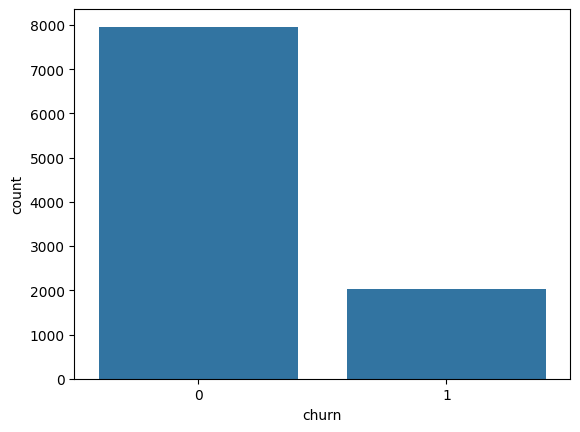

In [36]:
# Chcę zobaczyć rozkład wartości w kolumnie 'churn'
sns.countplot(x='churn', data=data)

Wniosek: Ze względu na niezbalansowanie klas (klientów odchodzących jest dużo mniej) musimy uważać podczas dzielenia danych na treningowe i testowe.

In [37]:
X = data.drop('churn', axis=1)
y = data['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=24)

In [38]:
# to_remove = {'customer_id', 'credit_card', 'active_member', 'churn'}

# num_cols = [col for col in numerical_cols if col not in to_remove]
# print(num_cols)

# scaler = StandardScaler()
# X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# X_test[num_cols] = scaler.transform(X_test[num_cols])

In [39]:
# oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

# X_train_encoded = oh_encoder.fit_transform(X_train[categorical_cols])
# X_test_encoded = oh_encoder.transform(X_test[categorical_cols])

# X_train_final = pd.concat([X_train.drop(categorical_cols, axis=1), X_train_encoded], axis=1)
# X_test_final = pd.concat([X_test.drop(categorical_cols, axis=1), X_test_encoded], axis=1)

In [40]:
to_remove = {'customer_id', 'credit_card', 'active_member', 'churn'}

num_cols = [col for col in numerical_cols if col not in to_remove]
print(num_cols)

['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']


In [41]:
preprocessor = ColumnTransformer([
	('num', StandardScaler(), num_cols),
	('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas'), categorical_cols)
])

### 3. EDA

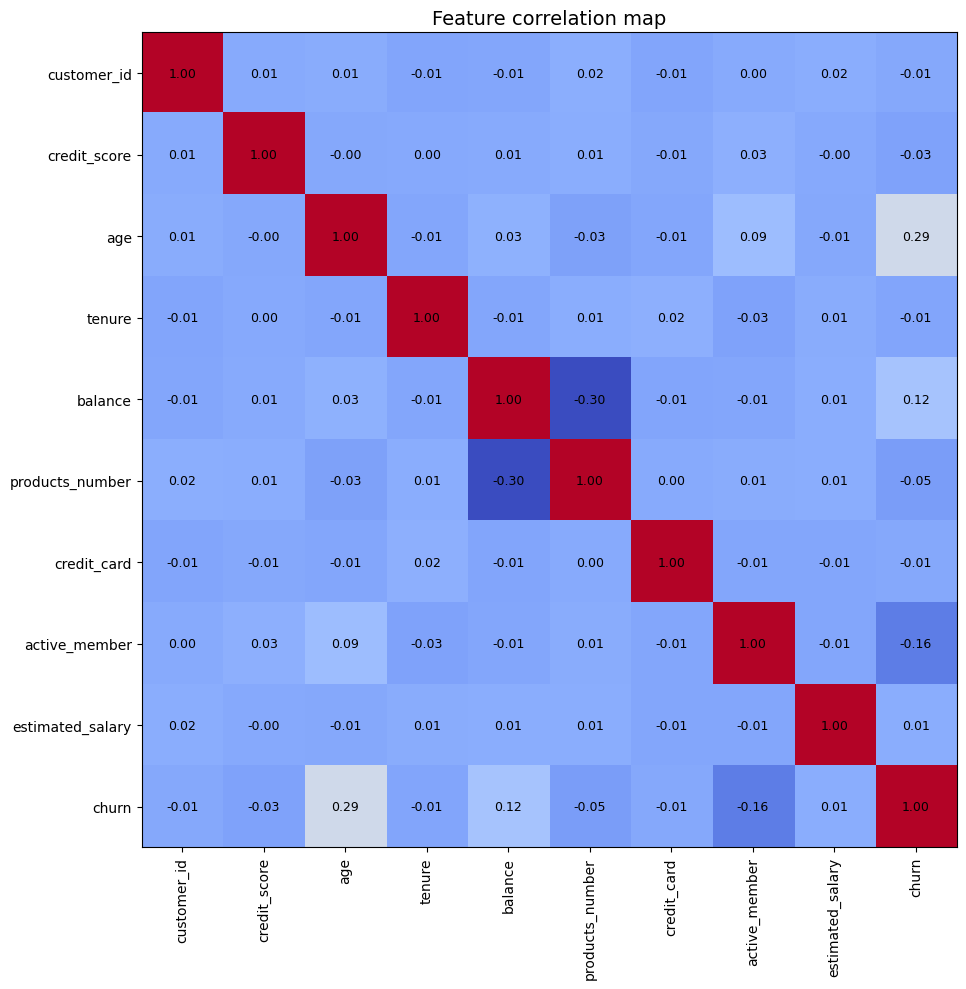

In [42]:
data_for_heatmap = data[numerical_cols]
corr_matrix = data_for_heatmap.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

ticks = np.arange(len(corr_matrix.columns))
plt.xticks(ticks=ticks, labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=ticks, labels=corr_matrix.columns)
plt.title('Feature correlation map', fontsize=14)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                 ha='center', va='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()

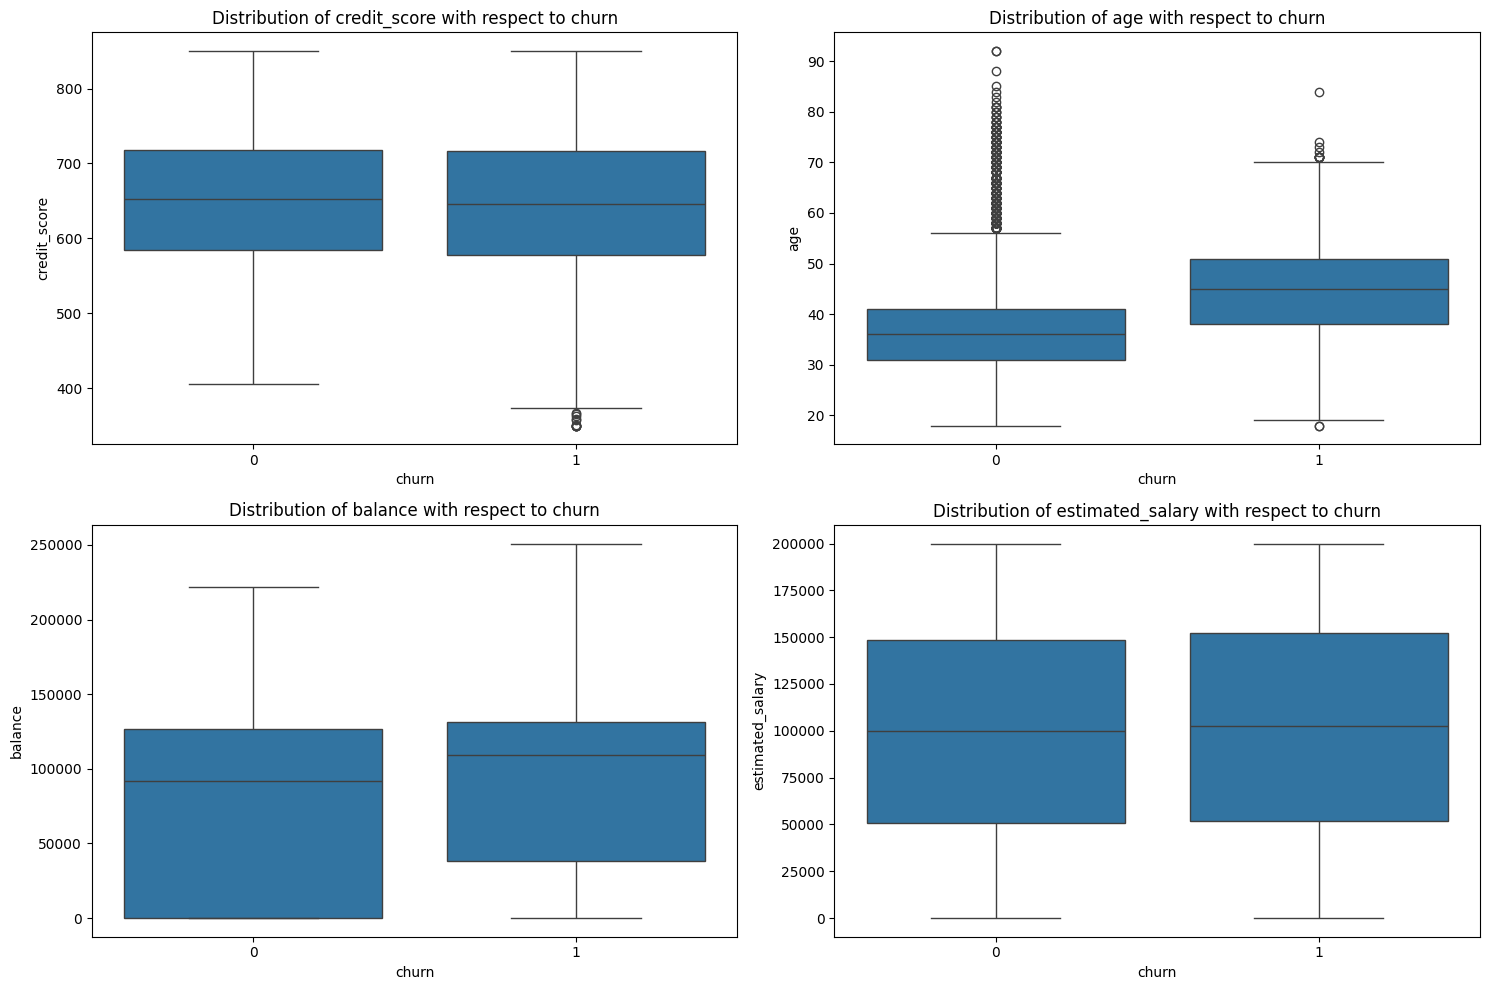

In [43]:
cols_to_plot = ['credit_score', 'age', 'balance', 'estimated_salary']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='churn', y=col, data=data)
    plt.title(f'Distribution of {col} with respect to churn')

plt.tight_layout()
plt.show()

In [44]:
# # Robię SMOTE żeby zmniejszyć niezbalansowanie danych
# smote = SMOTE(random_state=24)

# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

# print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
# print(f"After SMOTE: {y_train_resampled.value_counts().to_dict()}")

# X_train_final = X_train_resampled
# y_train = y_train_resampled

In [45]:
# # ------------------- LogisticRegression -------------------
# lr_model = LogisticRegression(random_state=24)
# lr_model.fit(X_train_final, y_train)
# lr_predict = lr_model.predict(X_test_final)

# lr_result = classification_report(y_test, lr_predict)
# print('=' * 60)
# print(f'{' ' * 15}Logistic Regression results \n\n{lr_result}')
# print('=' * 60)

# # ------------------- RandomForestClassifier -------------------
# rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=24)
# rf_model.fit(X_train_final, y_train)
# rf_predict = rf_model.predict(X_test_final)

# rf_result = classification_report(y_test, rf_predict)
# print('=' * 60)
# print(f'{' ' * 15}Random Forest results \n\n{rf_result}')
# print('=' * 60)

# # ------------------- XGBClassifier -------------------
# xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=24, use_label_encoder=False, eval_metric='logloss')
# xgb_model.fit(X_train_final, y_train)
# xgb_predict = xgb_model.predict(X_test_final)

# xgb_result = classification_report(y_test, xgb_predict)
# print('=' * 60)
# print(f'{' ' * 15}XGB results \n\n{xgb_result}')
# print('=' * 60)

In [46]:
models = {
	'Logistic Regression': {
		'model': LogisticRegression(solver='liblinear', random_state=24),
		'params': {
			'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l1', 'l2'],
		}
	},
	'Random Forest': {
		'model': RandomForestClassifier(class_weight='balanced', random_state=24),
		'params': {
			'classifier__n_estimators': [100, 200, 300],
			'classifier__max_depth': [None, 10, 20],
		}
	},
	'XGBoost': {
		'model': XGBClassifier(eval_metric='logloss', random_state=24),
		'params': {
			'classifier__n_estimators': [100, 200, 300],
			'classifier__max_depth': [3, 5, 8],
			'classifier__learning_rate': [0.05, 0.1],
		}
	}
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)
results = []

for name, config in models.items():
	pipeline = Pipeline([
		('preprocessor', preprocessor),
		('smote', SMOTE(random_state=24)),
		('classifier', config['model'])
	])

	search = GridSearchCV(
		estimator=pipeline,
		param_grid=config['params'],
		cv=skf,
		scoring='roc_auc',
		n_jobs=-1
	)

	search.fit(X_train, y_train)

	results.append({
        'model': name,
        'best_params': search.best_params_,
        'cv_auc': search.best_score_,
        'best_estimator': search.best_estimator_
    })
	
	print(f"{name}: AUC = {search.best_score_:.3f}")

results_sorted = sorted(results, key=lambda x: x['cv_auc'], reverse=True)
best = results_sorted[0]
print(f"\nNajlepszy model: {best['model']} (AUC = {best['cv_auc']:.3f})")

# print(results)

Logistic Regression: AUC = 0.759
Random Forest: AUC = 0.847
XGBoost: AUC = 0.850

Najlepszy model: XGBoost (AUC = 0.850)


In [47]:
for model in results:
    model_report = classification_report(y_test, model['best_estimator'].predict(X_test))
    print('=' * 60)
    print(f'{' ' * 15}{model['model']} results \n\n{model_report}')
    print('=' * 60)


               Logistic Regression results 

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.69      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.80      0.71      0.74      2000

               Random Forest results 

              precision    recall  f1-score   support

           0       0.91      0.84      0.87      1593
           1       0.52      0.68      0.59       407

    accuracy                           0.81      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.81      0.82      2000

               XGBoost results 

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1593
           1       0.60      0.60      0.60       407

    accuracy                           0.84      2000
   macro av

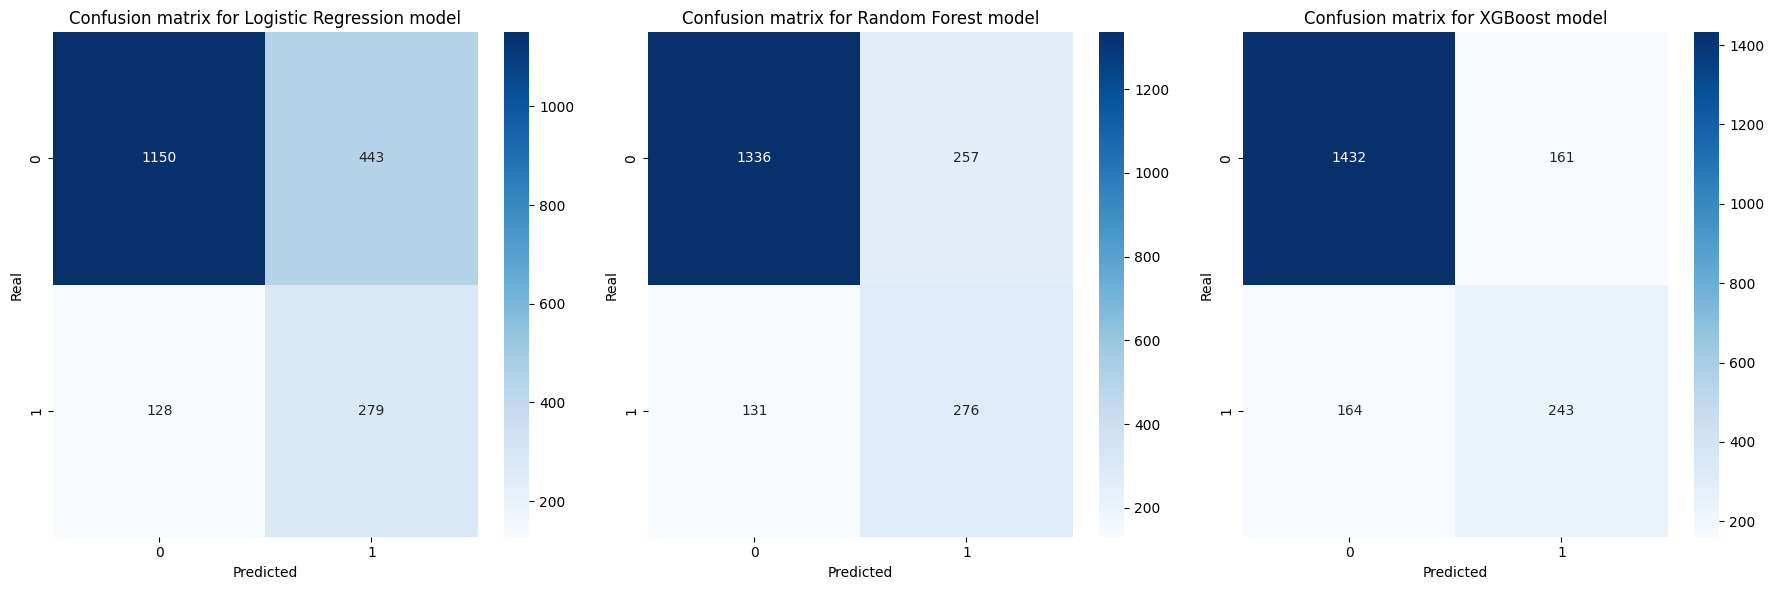

In [48]:
models_pred = []

for model in results:
    models_pred.append((
        model['best_estimator'].predict(X_test), model['model']
	))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for ax, (pred, name) in zip(axes, models_pred):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion matrix for {name} model')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

AUC for Logistic Regression: 0.748
AUC for Random Forest: 0.851
AUC for XGBoost: 0.852


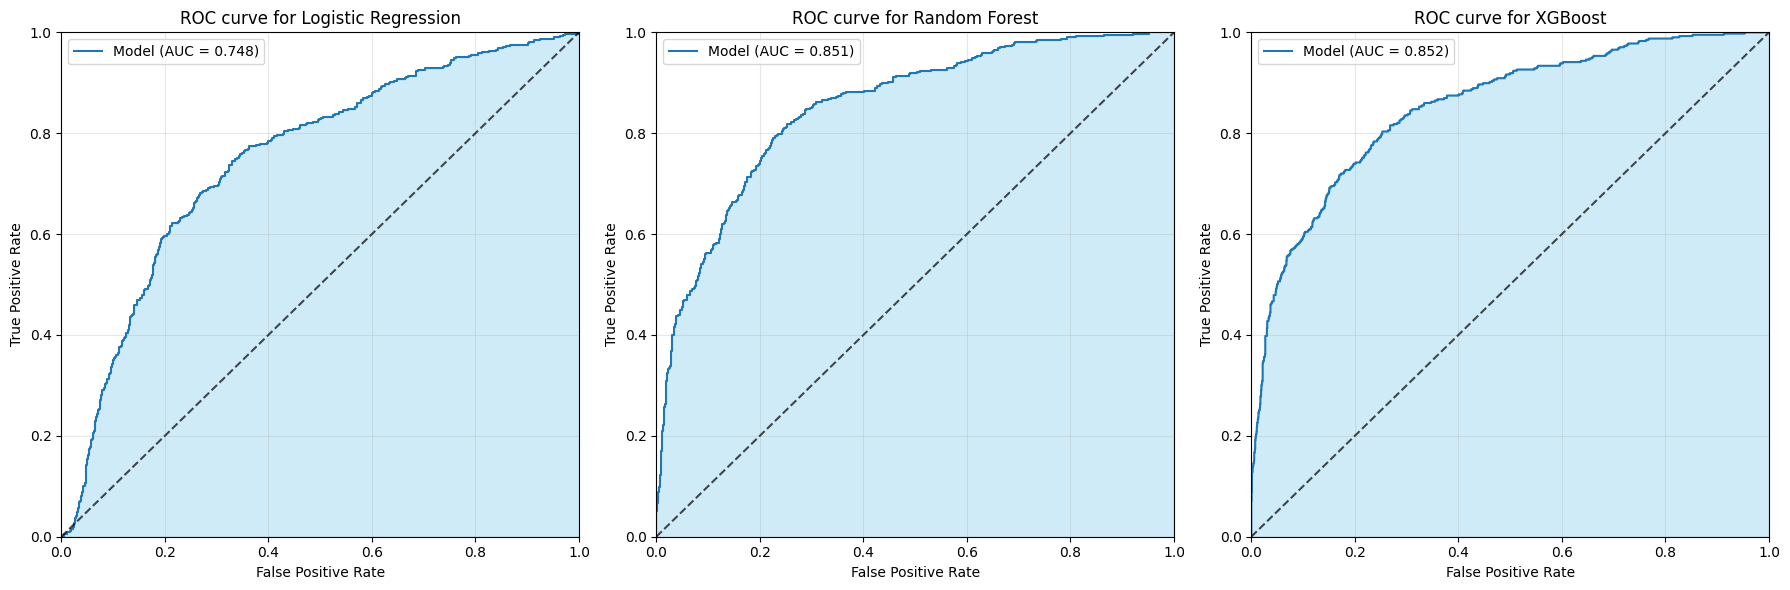

In [49]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for ax, model in zip(axes, results):
    probs = model['best_estimator'].predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    ax.plot(fpr, tpr, label=f'Model (AUC = {auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax.fill_between(fpr, tpr, color="skyblue", alpha=0.4)
    ax.set_title(f'ROC curve for {model['model']}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    
    print(f"AUC for {model['model']}: {auc:.3f}")

plt.tight_layout()
plt.show()

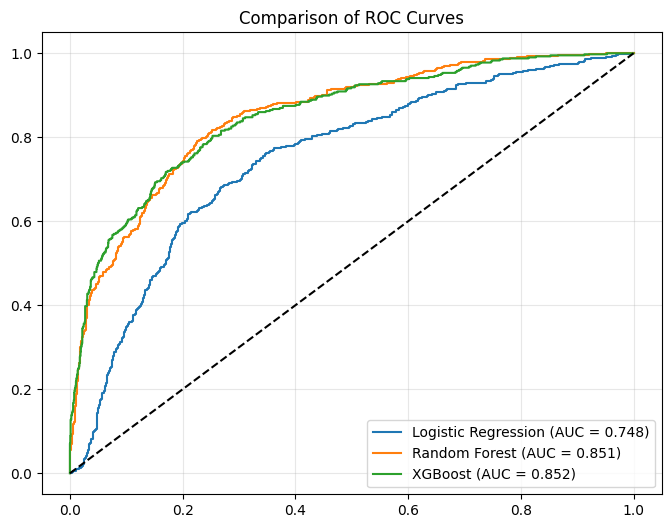

In [50]:
plt.figure(figsize=(8, 6))

for model in results:
    probs = model['best_estimator'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model['model']} (AUC = {auc:.3f})')

plt.grid(True, alpha=0.3)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Comparison of ROC Curves')
plt.legend()
plt.show()